Show the vector components of the flux surface normal vector.

In [277]:
import numpy as np
from matplotlib import pyplot as plt
from contourpy import contour_generator
from scipy import interpolate

def gen_contour_array(xgrid, mugrid, psi_grid, psi_levels):

    cont_gen = contour_generator(mugrid, xgrid, psi_grid, quad_as_tri=True)
    lines_arr_0 = np.array(cont_gen.lines(psi_levels[0]))[0]
    contour_array = np.hstack((lines_arr_0,np.reshape(np.zeros(len(lines_arr_0)),(-1,1))))

    for index in range(1,len(psi_levels)):
        # check if cont_gen.lines() returns an empty array:
        if(len(cont_gen.lines(psi_levels[index])) == 0):
            continue
        else:
            lines = np.array(cont_gen.lines(psi_levels[index])[0])
            contour_array = np.append(contour_array, np.hstack((lines, np.reshape(index*np.ones(len(lines)), (-1,1)))), axis=0)

    # remove any contour coordinates below some limit xlim:
    # contour_array_output = contour_array[((contour_array[:,1] < 1.e-10))|(contour_array[:,1] > 1.e-3)]

    return contour_array

def interpolate_function(data, mu, x, dmu, dx, LOGSCALEX, X1LOW):

    # Calc Nx, Nmu:
    nx = data.shape[0]
    nmu = data.shape[1]

    # Find base point, and distance of (mu,x) from the base point
    if(LOGSCALEX == 1):
        x1 = np.log(x + np.exp(-X1LOW)) + X1LOW
    else:
        x1 = x

    if((np.abs(x1/dx - np.rint(x1/dx)) > 1e-10) & (np.abs(x1/dx - np.rint(x1/dx)) < 1e-4)):
        ix = int(np.rint(x1/dx))
        xs=0.0
    else:
        ix = int(np.floor(x1/dx))
        xs = x1/dx - ix

    imu = int(np.floor(mu/dmu))
    mus = mu/dmu - imu

    if((ix < nx - 1) & (imu < nmu - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu+1]
        data2 = data[ix+1, imu]
        data3 = data[ix+1, imu+1]
        
    if((ix == nx - 1) & (imu < nmu - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu+1]
        data2 = 0
        data3 = 0

    if((imu == nmu - 1) & (ix < nx - 1)):
        data0 = data[ix, imu]
        data1 = 0
        data2 = data[ix+1, imu]
        data3 = 0

    if((imu == nmu - 1) & (ix == nx - 1)):
        data0 = data[ix, imu]
        data1 = data[ix, imu]
        data2 = data[ix, imu]
        data3 = data[ix, imu]

    interpolant = xs*mus*data3 + (1-mus)*xs*data2 + mus*(1-xs)*data1 + (1-xs)*(1-mus)*data0

    return interpolant

R_star = 1e4
R_max = 4*R_star
x0 = 0.538
aratio = R_star/x0
r = np.linspace(R_star,R_max,100)
x = (r - R_star)/x0
# theta = np.linspace(0, np.pi/2,100)

mu = np.linspace(0,1,100)

mu_levels = np.flip(mu)
mug,xg = np.meshgrid(mu,x)
psi_grid = (1. - mug**2)/x0/(xg+aratio)
psi_levels = (1. - mu_levels**2)/x0/aratio

contour_array = gen_contour_array(xg,mug,psi_grid,psi_levels)

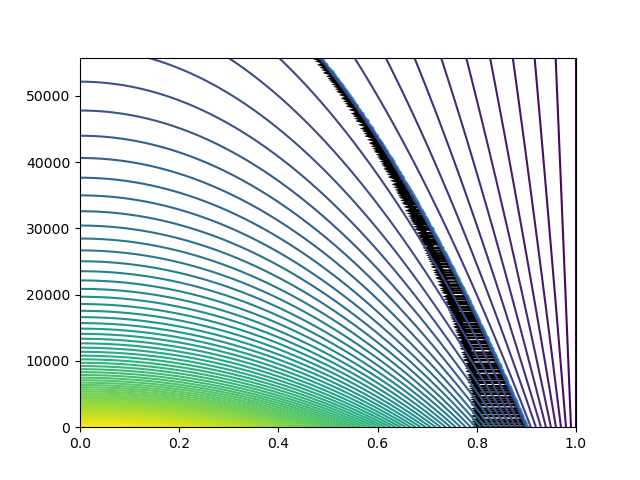

In [316]:
index = 10
mu_c = contour_array[contour_array[:,2] == index][:,0]
x_c = contour_array[contour_array[:,2] == index][:,1]

gradx_grid,gradmu_grid = np.gradient(psi_grid,xg[:,0],mug[0,:],edge_order=2)
gradx_grid_analytic = -(1 - mug**2)/x0/(xg+aratio)**2
gradmu_grid_analytic = -2*mug/x0/(xg+aratio)

# fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
# cb=ax.contourf(mug,xg,gradmu_grid,levels=100)
# ax.scatter(mu_c,x_c)
# fig.colorbar(cb,ax=ax)
# cb2 = ax2.contourf(mug,xg,gradmu_grid_analytic,levels=100)
# fig.colorbar(cb2,ax=ax2)
# plt.show()
LOGSCALEX = 0
X1LOW= 0
dx = xg[1,0] - xg[0,0]
dmu = mug[0,1] - mug[0,0]
gradx_c = np.array([interpolate_function(gradx_grid, mu_c[i],x_c[i],dmu,dx,LOGSCALEX,X1LOW) for i in range(len(mu_c))])
gradmu_c = np.array([interpolate_function(gradmu_grid, mu_c[i],x_c[i],dmu,dx,LOGSCALEX,X1LOW) for i in range(len(mu_c))])

xxgrid = xg*np.sin(thg)
yygrid = xg*np.cos(thg)

xx_c = x_c*np.sqrt(1 - mu_c**2)
yy_c = x_c * mu_c

%matplotlib widget
kk = np.arange(0,len(mu_c),2)
fig,ax = plt.subplots()
ax.contour((mug),xg,psi_grid,levels=psi_levels)
ax.scatter((mu_c),x_c,s=10,alpha = 0.5)
ax.quiver(mu_c[kk],x_c[kk],gradmu_c[kk],gradx_c[kk])
plt.show()

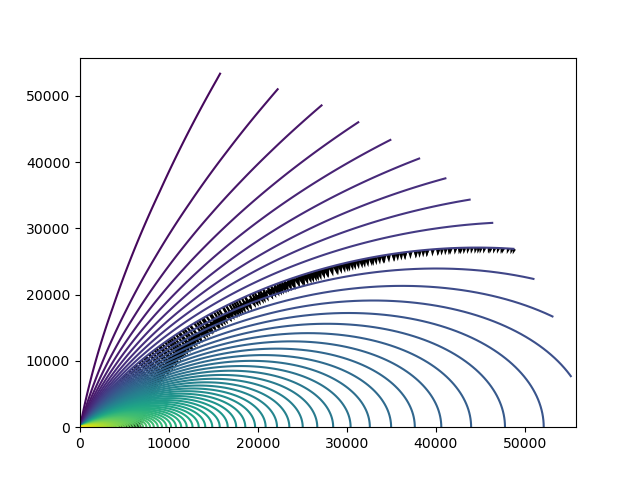

In [317]:
fig,ax = plt.subplots()
ax.contour(xxgrid,yygrid,psi_grid,levels=psi_levels)
ax.scatter(f_xx_c,f_yy_c,s=10,alpha = 0.5)
# gradxx_c = xx_c[kk]/x_c[kk]*gradx_c[kk] - xx_c[kk]/(yy_c[kk]**2*(x_c[kk]**2/yy_c[kk]**2)**1.5)*gradmu_c[kk]
# gradyy_c = yy_c[kk]/x_c[kk]*gradx_c[kk] + xx_c[kk]**2/(yy_c[kk]**3*(x_c[kk]**2/yy_c[kk]**2)**1.5)*gradmu_c[kk]
gradxx_c = (np.sqrt(1 - mu_c[kk]**2)*gradx_c[kk] - np.sqrt(1-mu_c[kk]**2)*mu_c[kk]/(x_c[kk]+aratio)*gradmu_c[kk])/x0
gradyy_c = (mu_c[kk]*gradx_c[kk] + (1 - mu_c[kk]**2)/(x_c[kk]+aratio)*gradmu_c[kk])/x0
ax.quiver(xx_c[kk],yy_c[kk],gradxx_c,gradyy_c,angles='xy',scale_units='xy')
# ax.set_aspect('equal')
plt.show()

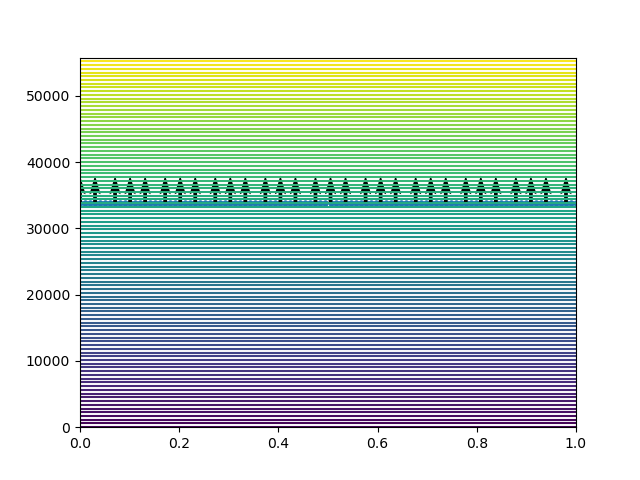

In [318]:
f = x0*(xg+aratio)
f_levels = np.linspace(x0*(xg[0,0]+aratio),x0*(xg[-1,0]+aratio),100)
f_contour_array = gen_contour_array(xg,mug,f,f_levels)

index_2 = 60
mu_c = f_contour_array[f_contour_array[:,2] == index_2][:,0]
x_c = f_contour_array[f_contour_array[:,2] == index_2][:,1]

f_gradx_grid,f_gradmu_grid = np.gradient(f,xg[:,0],mug[0,:],edge_order=2)

f_itp_mu = interpolate.RegularGridInterpolator((mug[0,:],xg[:,0]),f_gradmu_grid)
f_itp_x = interpolate.RegularGridInterpolator((mug[0,:],xg[:,0]),f_gradx_grid)

f_gradx_c = f_itp_x((mu_c,x_c))
f_gradmu_c = f_itp_mu((mu_c,x_c))
f_xx_c = x_c*np.sqrt(1 - mu_c**2)
f_yy_c = x_c * mu_c
kk = np.arange(0,len(mu_c),10)

f_gradxx_c = (np.sqrt(1 - mu_c[kk]**2)*f_gradx_c[kk] - np.sqrt(1-mu_c[kk]**2)*mu_c[kk]/(x_c[kk]+aratio)*f_gradmu_c[kk])/x0
f_gradyy_c = (mu_c[kk]*f_gradx_c[kk] + (1 - mu_c[kk]**2)/(x_c[kk]+aratio)*f_gradmu_c[kk])/x0
# r_c = np.sqrt(f_xx_c**2 + f_yy_c**2)
# f_gradxx_c = f_xx_c/r_c*f_gradx_c
# f_gradyy_c = f_yy_c/r_c*f_gradx_c

fig,ax = plt.subplots()
ax.contour(mug,xg,f,levels=f_levels)
ax.scatter(mu_c,x_c,s=10)
ax.quiver(mu_c[kk],x_c[kk],f_gradmu_c[kk]*np.sqrt(1-mu_c[kk]**2)/(x_c[kk]+aratio),f_gradx_c[kk],angles='xy',scale_units='xy')
plt.show()

# fig,ax = plt.subplots()
# ax.contour(xxgrid,yygrid, f,levels=f_levels)
# ax.scatter(f_xx_c,f_yy_c,s=10,alpha = 0.5)
# ax.quiver(f_xx_c[kk],f_yy_c[kk],f_gradxx_c,f_gradyy_c,angles='xy',scale_units='xy')

# ax.set_aspect("equal")
# plt.show()

Check whether, when plotting in $(r,\theta)$ space, the gradient vector requires the scale factors.

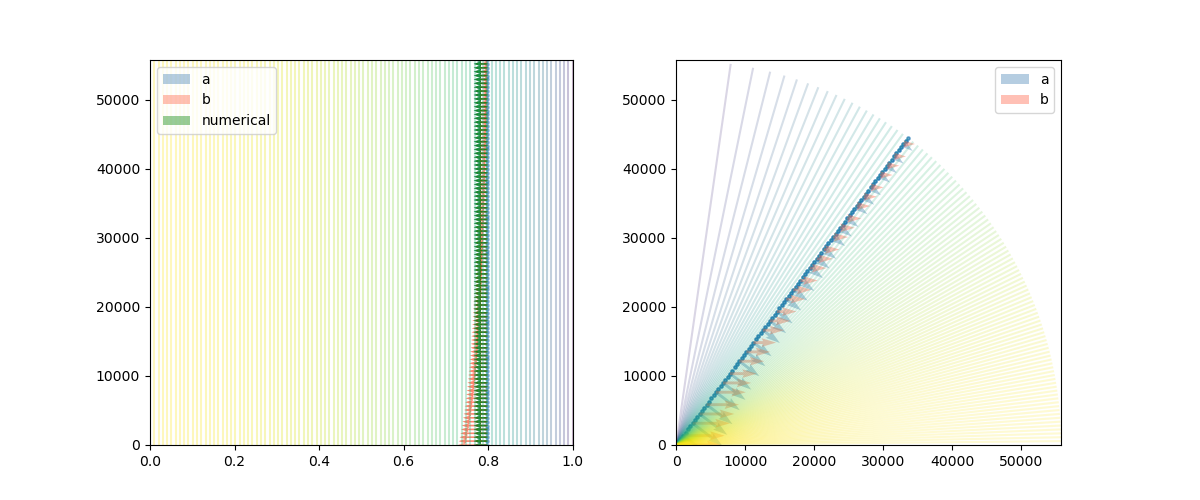

In [350]:

g = np.sqrt(1. - mug**2)
g_levels = np.sqrt(1 - mu_levels**2)
contour_array = gen_contour_array(xg,mug,g,g_levels)
g_index = 20
g_mu_c = contour_array[contour_array[:,2]==g_index][:,0]
g_x_c = contour_array[contour_array[:,2]==g_index][:,1]

g_gradx_grid,g_gradmu_grid = np.gradient(g,xg[:,0],mug[0,:],edge_order=2)
g_gradx_c = np.array([interpolate_function(gradx_grid, g_mu_c[i],x_c[i],dmu,dx,LOGSCALEX,X1LOW) for i in range(len(g_mu_c))])
g_gradmu_c = np.array([interpolate_function(gradmu_grid, g_mu_c[i],x_c[i],dmu,dx,LOGSCALEX,X1LOW) for i in range(len(g_mu_c))])

g_gradmu_a_analytic = -g_mu_c/np.sqrt(1. - g_mu_c**2)
g_gradmu_b_analytic = -g_mu_c/(g_x_c + aratio)
g_gradx_c_analytic = np.zeros_like(g_gradmu_a)

g_xx_c = g_x_c*np.sqrt(1. - g_mu_c**2)
g_yy_c = g_x_c * g_mu_c

kk = np.arange(0,len(g_mu_c),10)

g_gradxx_a = (np.sqrt(1 - g_mu_c[kk]**2)*g_gradx_c_analytic[kk] - np.sqrt(1-g_mu_c[kk]**2)*g_mu_c[kk]/(g_x_c[kk]+aratio)*g_gradmu_a_analytic[kk])/x0
g_gradyy_a = (g_mu_c[kk]*g_gradx_c[kk] + (1 - g_mu_c[kk]**2)/(g_x_c[kk]+aratio)*g_gradmu_a[kk])/x0

g_gradxx_b = (np.sqrt(1 - g_mu_c[kk]**2)*g_gradx_c_analytic[kk] - np.sqrt(1-g_mu_c[kk]**2)*g_mu_c[kk]/(g_x_c[kk]+aratio)*g_gradmu_b_analytic[kk])/x0
g_gradyy_b = (g_mu_c[kk]*g_gradx_c_analytic[kk] + (1 - g_mu_c[kk]**2)/(g_x_c[kk]+aratio)*g_gradmu_b_analytic[kk])/x0

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.contour(mug,xg,g,levels=g_levels,alpha = 0.3)
ax.scatter(g_mu_c,g_x_c,s=5,alpha =0.2)
ax.quiver(g_mu_c,g_x_c,g_gradmu_a,g_gradx_c,angles='xy',scale_units='xy',label='a',alpha = 0.4,color='steelblue')
ax.quiver(g_mu_c,g_x_c,g_gradmu_b,g_gradx_c,angles='xy',scale_units='xy',label='b',alpha = 0.4,color='tomato')
ax.quiver(g_mu_c,g_x_c,g_gradmu_c,g_gradx_c,angles='xy',scale_units='xy',label='numerical',alpha = 0.4,color='green')

ax.legend()
ax2.contour(xxgrid,yygrid,g,levels=g_levels,alpha = 0.2)
ax2.scatter(g_xx_c,g_yy_c,s=5,alpha = 0.4)
ax2.quiver(g_xx_c[kk],g_yy_c[kk],g_gradxx_c,g_gradyy_a,angles='xy',scale_units='xy',label='a',alpha = 0.4,color='steelblue')
ax2.quiver(g_xx_c[kk],g_yy_c[kk],g_gradxx_c,g_gradyy_b,angles='xy',scale_units='xy',label='b',alpha = 0.4,color='tomato')
ax2.legend()
ax2.set_aspect('equal')
plt.show()

Conclusion: when plotting in $(r,\theta)$ coordinates, the normal vector looks like $\nabla f = \frac{\partial f}{\partial r}\hat{\mathbf{e}}_r +  \frac{\partial f}{\partial \theta}\hat{\mathbf{e}}_\theta$ - it is only when converting to a different coordinate system that you need the scale factors.